### The given dataset contains various attributes related to individual music tracks. Key features include:e track.

- Energy: A measure of intensity and activity.
- Valence: A measure of the musical positiveness conveyed by a track.
- Danceability: Describes how suitable a track is for dancing.
- Loudness: Overall loudness of a track in decibels (dB).
- Acousticness: Confidence measure of whether the track is acoustic.
- Tempo: The speed or pace of a given piece, measured in beats per minute (BPM).
- Speechiness: Measures the presence of spoken words in a track.
- Liveness: Detects the presence of an audience in the recording.
- Popularity: The target variable indicating the popularity score of the track.

### Problem 

The objective is to develop a predictive model that can accurately estimate the popularity of music tracks based on their audio features. Accurate predictions of music popularity can assist music streaming platforms in better understanding user preferences, enhancing recommendation systems, and optimizing playlists to boost user engagement.

Specifically, the goal is to build a regression model using machine learning techniques to predict the popularity score of a track by finding the most relevant features.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings as w
w.filterwarnings("ignore")
plt.style.use("ggplot")
sns.set_style("whitegrid")

In [3]:
df = pd.read_csv(r"C:\Users\areeb\Desktop\Personal Projects\Data Sets\Spotify_data.csv")

In [16]:
pd.set_option('display.max_columns',100)

In [19]:
df.head(3)

,Unnamed: 0,Track Name,Artists,Album Name,Album ID,Track ID,Popularity,Release Date,Duration (ms),Explicit,External URLs,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
0,0,Not Like Us,Kendrick Lamar,Not Like Us,5JjnoGJyOxfSZUZtk2rRwZ,6AI3ezQ4o3HUoP6Dhudph3,96,2024-05-04,274192,True,https://open.spotify.com/track/6AI3ezQ4o3HUoP6...,0.898,0.472,1,-7.001,1,0.0776,0.0107,0.000000,0.1410,0.214,101.061
1,1,Houdini,Eminem,Houdini,6Xuu2z00jxRPZei4IJ9neK,2HYFX63wP3otVIvopRS99Z,94,2024-05-31,227239,True,https://open.spotify.com/track/2HYFX63wP3otVIv...,0.936,0.887,9,-2.760,0,0.0683,0.0292,0.000002,0.0582,0.889,127.003
2,2,BAND4BAND (feat. Lil Baby),"Central Cee, Lil Baby",BAND4BAND (feat. Lil Baby),4AzPr5SUpNF553eC1d3aRy,7iabz12vAuVQYyekFIWJxD,91,2024-05-23,140733,True,https://open.spotify.com/track/7iabz12vAuVQYye...,0.882,0.764,11,-5.241,1,0.2040,0.3590,0.000000,0.1190,0.886,140.113


In [91]:
df.shape

(227, 22)

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 227 entries, 0 to 226
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        227 non-null    int64  
 1   Track Name        227 non-null    object 
 2   Artists           227 non-null    object 
 3   Album Name        227 non-null    object 
 4   Album ID          227 non-null    object 
 5   Track ID          227 non-null    object 
 6   Popularity        227 non-null    int64  
 7   Release Date      227 non-null    object 
 8   Duration (ms)     227 non-null    int64  
 9   Explicit          227 non-null    bool   
 10  External URLs     227 non-null    object 
 11  Danceability      227 non-null    float64
 12  Energy            227 non-null    float64
 13  Key               227 non-null    int64  
 14  Loudness          227 non-null    float64
 15  Mode              227 non-null    int64  
 16  Speechiness       227 non-null    float64
 1

In [93]:
df.describe()

,Unnamed: 0,Popularity,Duration (ms),Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
count,227.000000,227.00000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000,227.000000
mean,113.000000,71.85022,219254.881057,0.635639,0.646665,5.458150,-6.516670,0.678414,0.079576,0.375060,0.028890,0.177797,0.472441,119.466361
std,65.673435,10.24110,60483.492317,0.155123,0.159150,3.760738,2.099543,0.468117,0.085100,0.300084,0.137225,0.121366,0.193902,26.154889
min,0.000000,13.00000,96947.000000,0.271000,0.236000,0.000000,-15.073000,0.000000,0.024600,0.000307,0.000000,0.029700,0.038500,61.311000
25%,56.500000,68.00000,170554.500000,0.552000,0.539500,2.000000,-7.830000,0.000000,0.033800,0.065000,0.000000,0.101000,0.324500,95.457500
50%,113.000000,72.00000,222462.000000,0.634000,0.655000,6.000000,-6.346000,1.000000,0.042100,0.393000,0.000002,0.127000,0.462000,122.925000
75%,169.500000,78.00000,265611.000000,0.746000,0.763500,9.000000,-5.080500,1.000000,0.081200,0.630500,0.000170,0.219000,0.595000,137.952000
max,226.000000,96.00000,383639.000000,0.948000,0.972000,11.000000,-0.424000,1.000000,0.491000,0.940000,0.901000,0.790000,0.972000,187.629000


In [217]:
df.isnull().sum()

Track Name          0
Artists             0
Album Name          0
Album ID            0
Track ID            0
Popularity          0
Release Date        0
Duration (ms)       0
Explicit            0
External URLs       0
Danceability        0
Energy              0
Key                 0
Loudness            0
Mode                0
Speechiness         0
Acousticness        0
Instrumentalness    0
Liveness            0
Valence             0
Tempo               0
dtype: int64

In [97]:
df.drop(columns = "Unnamed: 0", axis = 1 , inplace =True)

In [106]:
numeric = df.select_dtypes(exclude= "object")
numeric.head(2)

,Popularity,Duration (ms),Explicit,Danceability,Energy,Key,Loudness,Mode,Speechiness,Acousticness,Instrumentalness,Liveness,Valence,Tempo
0,96,274192,True,0.898,0.472,1,-7.001,1,0.0776,0.0107,0.000000,0.1410,0.214,101.061
1,94,227239,True,0.936,0.887,9,-2.760,0,0.0683,0.0292,0.000002,0.0582,0.889,127.003


In [107]:
l = len(numeric.columns)
l

14

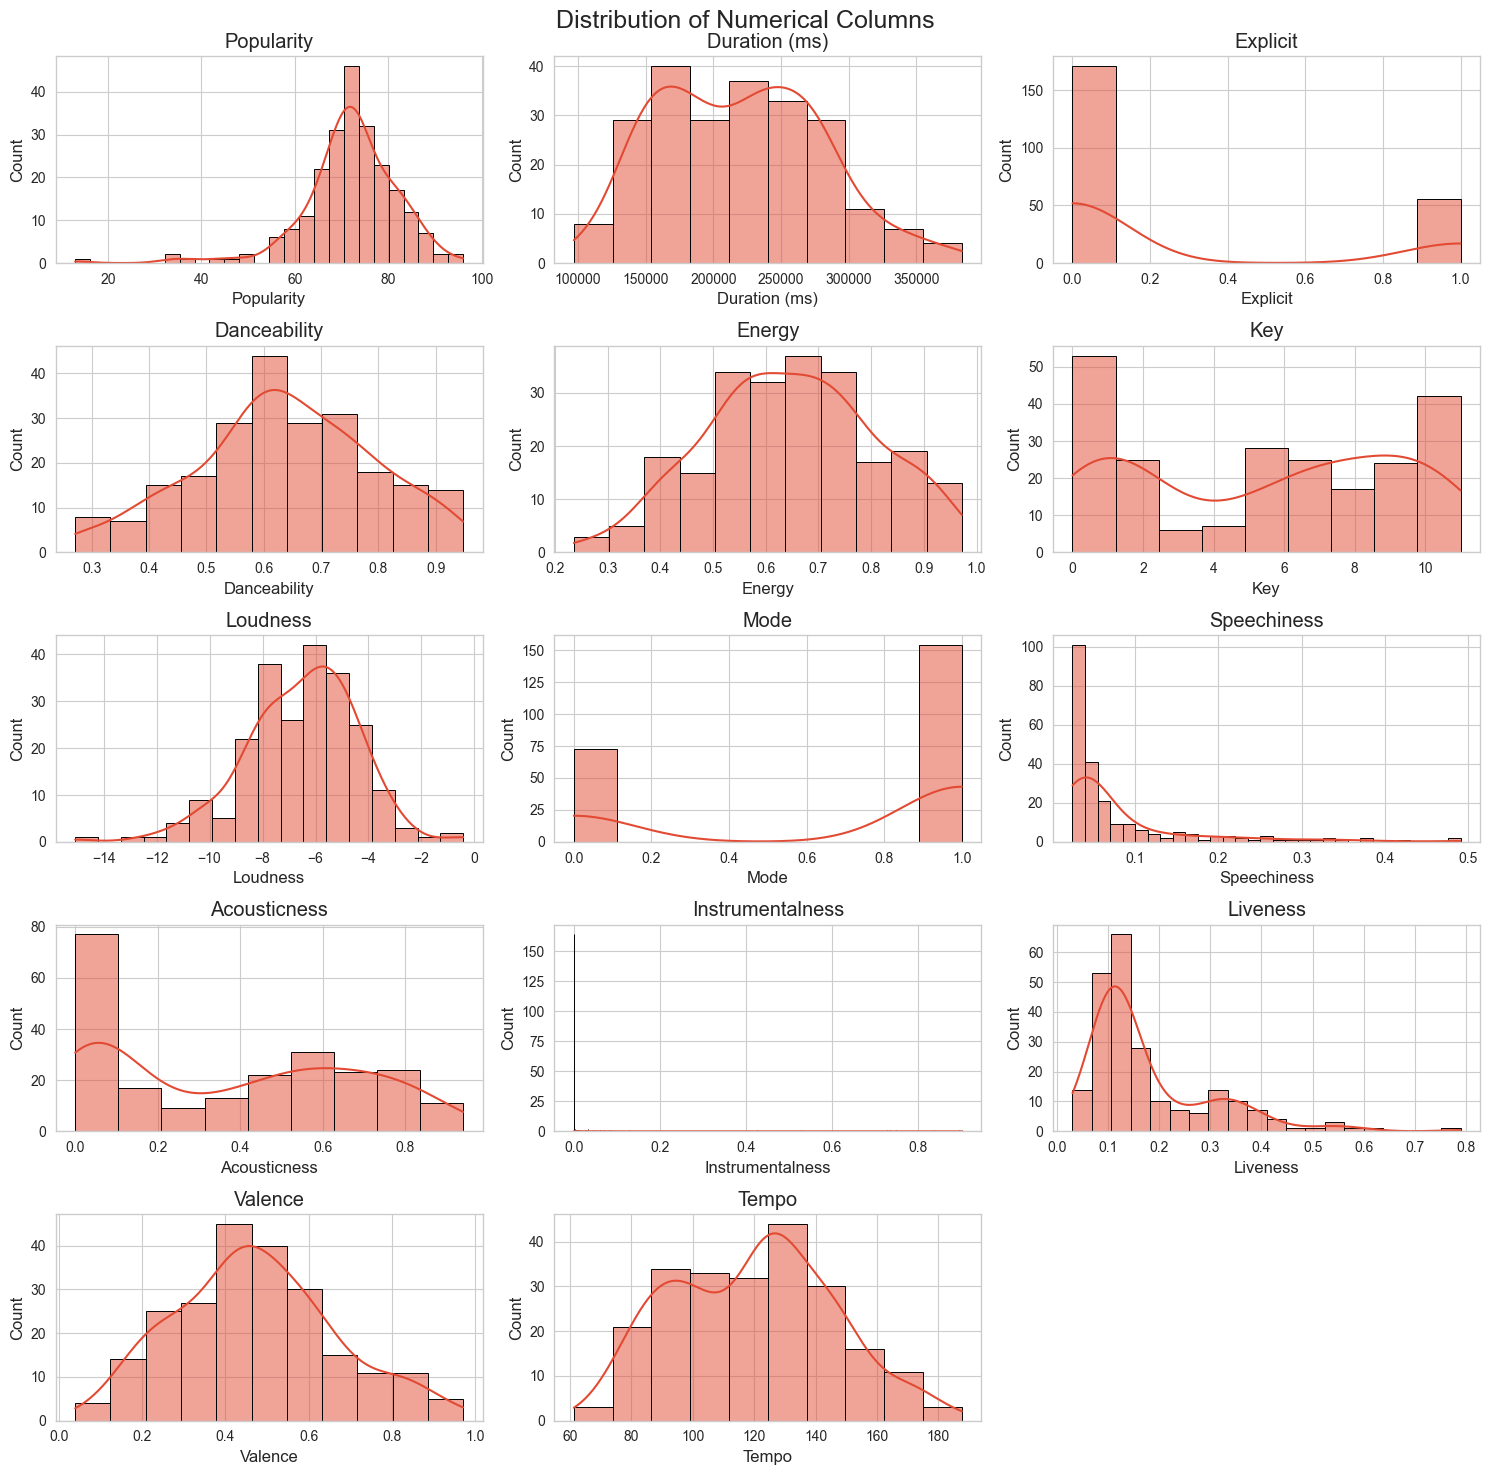

In [111]:
plt.figure( figsize = (15,15))

for index, i in enumerate(numeric.columns, start = 1):
    plt.subplot(5,3,index)
    sns.histplot(numeric[i], linewidth = 0.7, edgecolor = "k", kde = True)
    plt.title(i)

plt.suptitle("Distribution of Numerical Columns", size = 18)
plt.tight_layout()
plt.show()

In [115]:
from scipy.stats import describe

for i in numeric.columns:
    des = describe(numeric[i])
    print('\n')
    print(i)
    print(des)



Popularity
DescribeResult(nobs=227, minmax=(13, 96), mean=71.85022026431719, variance=104.88012163268488, skewness=-1.455566139457144, kurtosis=5.792131026077898)


Duration (ms)
DescribeResult(nobs=227, minmax=(96947, 383639), mean=219254.88105726874, variance=3658252842.857471, skewness=0.3037580183500095, kurtosis=-0.4899988638064432)


Explicit
DescribeResult(nobs=227, minmax=(False, True), mean=0.24669603524229075, variance=0.18665938949748542, skewness=1.1751837340128508, kurtosis=-0.6189431913116117)


Danceability
DescribeResult(nobs=227, minmax=(0.271, 0.948), mean=0.6356387665198238, variance=0.024063125570153204, skewness=-0.1665960410146241, kurtosis=-0.3944202075471259)


Energy
DescribeResult(nobs=227, minmax=(0.236, 0.972), mean=0.6466651982378855, variance=0.0253286042259561, skewness=-0.0518195306800513, kurtosis=-0.5511032609882922)


Key
DescribeResult(nobs=227, minmax=(0, 11), mean=5.458149779735683, variance=14.14315231374995, skewness=-0.10330497742677654, kurto

In [129]:
corr = numeric.corr()
corr["Popularity"].sort_values(ascending = False)

Popularity          1.000000
Explicit            0.405406
Loudness            0.308110
Danceability        0.251928
Energy              0.250068
Speechiness         0.190621
Tempo               0.131820
Instrumentalness    0.104846
Liveness            0.066110
Mode               -0.008246
Key                -0.008550
Valence            -0.045580
Duration (ms)      -0.269510
Acousticness       -0.431117
Name: Popularity, dtype: float64

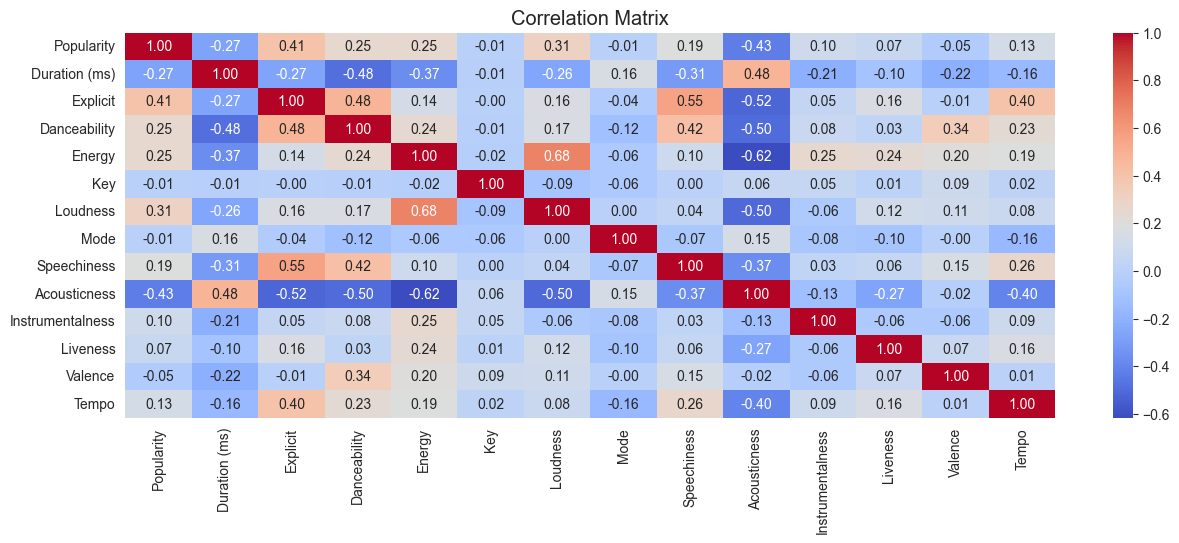

In [127]:
plt.figure(figsize = (15,5))
sns.heatmap(corr, annot = True, fmt= "1.2f", cmap = "coolwarm")

plt.title("Correlation Matrix")
plt.show()

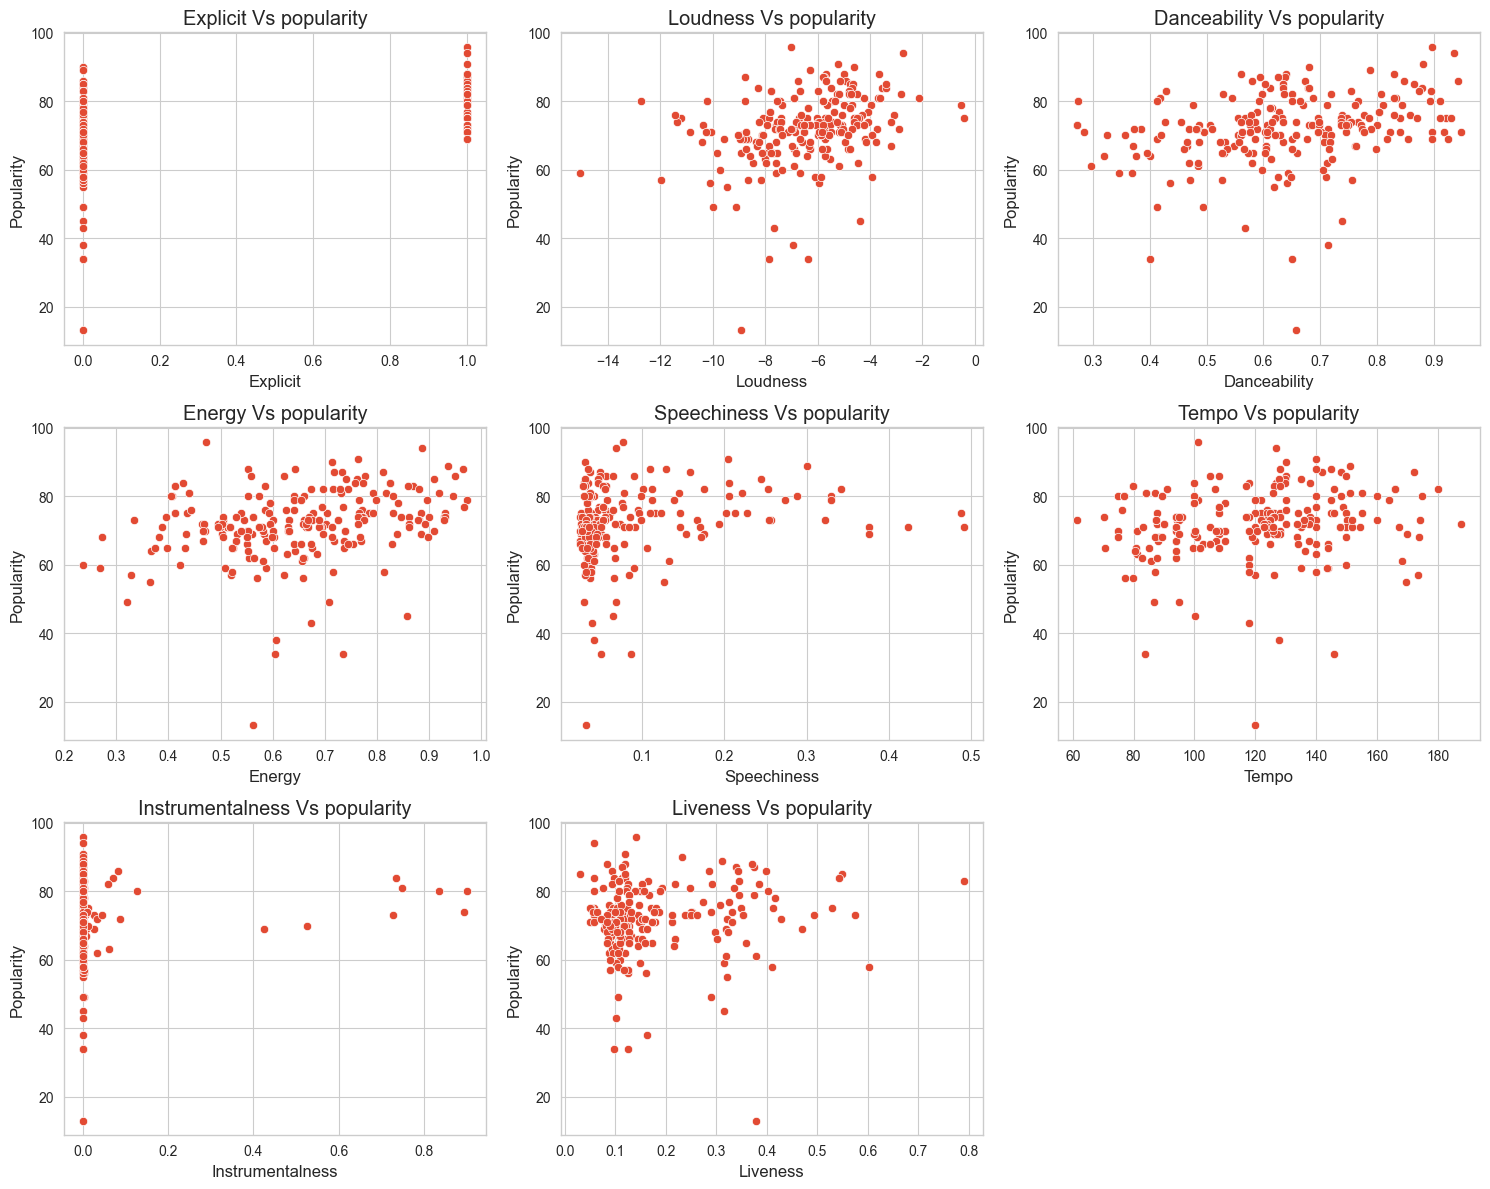

In [135]:
columns = ["Explicit", "Loudness" ,"Danceability" ,"Energy", "Speechiness","Tempo","Instrumentalness","Liveness"]

plt.figure(figsize = (15,12))

for index ,col in enumerate(columns, 1):
    plt.subplot(3,3,index)
    sns.scatterplot(data = df, x = col, y = "Popularity")
    plt.title(f'{col} Vs popularity')

plt.tight_layout()
plt.show()

In [178]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

In [145]:
columns = ["Explicit", "Loudness" ,"Danceability" ,"Energy", "Speechiness","Tempo","Instrumentalness","Liveness"]

x = df[columns]
y = df["Popularity"]

In [148]:
x_train, x_test , y_train, y_test = train_test_split(x,y, test_size = 0.25, random_state= 42)

In [151]:
x_train.shape

(170, 8)

In [152]:
x_test.shape

(57, 8)

In [153]:
y_train.shape

(170,)

In [155]:
y_test.shape

(57,)

In [156]:
sc = StandardScaler()

In [159]:
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [181]:
param = {
    'n_estimators': [50, 100, 200],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [182]:
rf = GridSearchCV( 
                    RandomForestRegressor(), 
                    param_grid = param, 
                    scoring = "neg_mean_squared_error",
                    cv = 5,
                    n_jobs = -1,
                )

In [188]:
rf.fit(x_train_scaled, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30, None],
                         'max_features': ['auto', 'sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='neg_mean_squared_error')

In [189]:
rf.best_params_

{'max_depth': 30,
 'max_features': 'sqrt',
 'min_samples_leaf': 2,
 'min_samples_split': 2,
 'n_estimators': 100}

In [191]:
rf_best = rf.best_estimator_
rf_best

RandomForestRegressor(max_depth=30, max_features='sqrt', min_samples_leaf=2)

In [192]:
train_pred = rf_best.predict(x_train_scaled)

In [193]:
train_r2_score = r2_score(y_train, train_pred)*100
train_r2_score

74.55058398446381

In [197]:
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
train_rmse

5.472804127975374

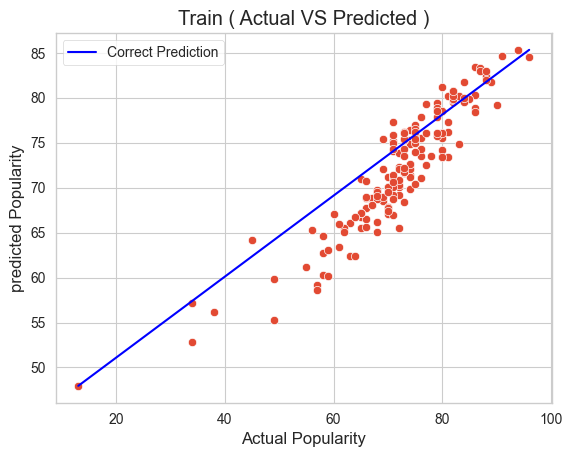

In [226]:
sns.scatterplot(x = y_train, y = train_pred)
plt.plot( [min(y_train),max(y_train)] , [min(train_pred), max(train_pred)], color = "blue" , label = "Correct Prediction")
plt.xlabel("Actual Popularity")
plt.ylabel("predicted Popularity")
plt.legend()
plt.title("Train ( Actual VS Predicted )")
plt.show()

In [195]:
test_pred = rf_best.predict(x_test_scaled)

In [196]:
test_r2_score = r2_score(y_test, test_pred)*100
test_r2_score

29.40687632344281

In [198]:
train_rmse = np.sqrt(mean_squared_error(y_test, test_pred))
train_rmse

6.738171811377568

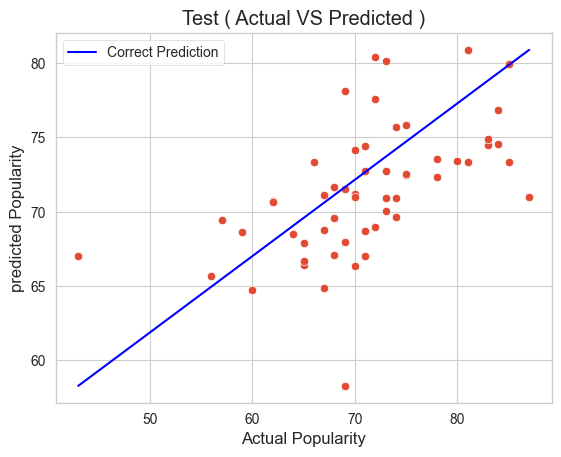

In [228]:
sns.scatterplot( x = y_test , y = test_pred )
sns.lineplot(x = [min(y_test), max(y_test)], y = [min(test_pred), max(test_pred)], color = "blue", label = "Correct Prediction")
plt.xlabel("Actual Popularity")
plt.ylabel("predicted Popularity")
plt.legend()
plt.title("Test ( Actual VS Predicted )")
plt.show()

In [252]:
feature_name = x.columns
feature_importance = rf_best.feature_importances_*100

In [253]:
fi = pd.DataFrame(data = feature_importance, index = feature_name, columns = ["Feature Importance"])
fi

,Feature Importance
Explicit,9.996894
Loudness,14.171994
Danceability,13.737252
Energy,17.532590
Speechiness,11.469206
Tempo,11.287009
Instrumentalness,9.550142
Liveness,12.254913


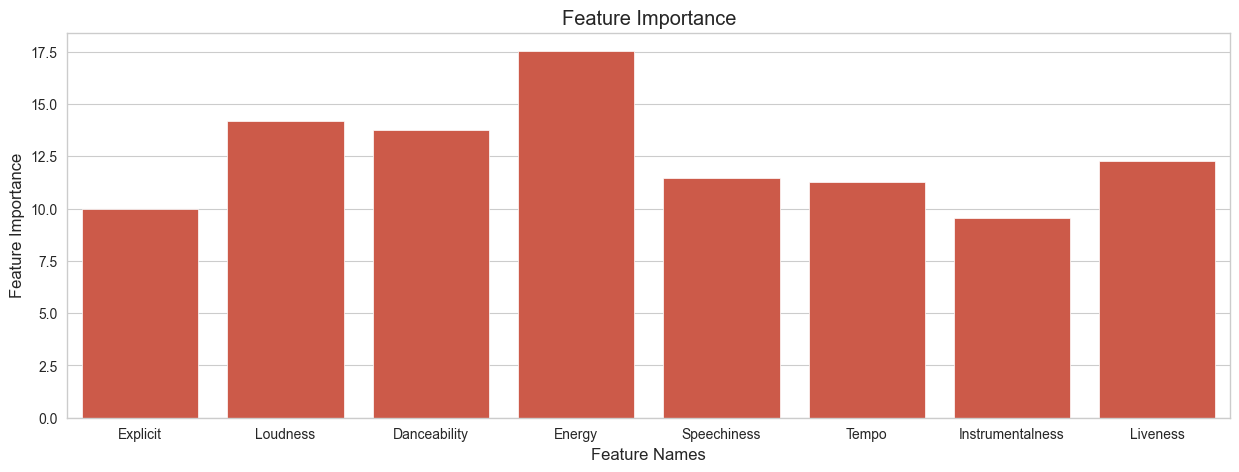

In [254]:
plt.figure( figsize = (15,5))
sns.barplot(data = fi, x = fi.index, y = "Feature Importance")
plt.title("Feature Importance")
plt.xlabel("Feature Names")
plt.show()